---
tags: [algorithm, optimization, variational]
---

# Quantum Approximate Optimization Algorithm (QAOA) for MaxCut

This tutorial walks through the Quantum Approximate Optimization Algorithm
(QAOA) pipeline step by step, using Qamomile's low-level circuit primitives.
Rather than using the high-level `QAOAConverter`, we will:

1. Define a MaxCut problem for a small graph.
2. Formulate it directly as an Ising model on spin variables.
3. Write the QAOA circuit step by step using `@qkernel`.
4. Optimize variational parameters with a classical optimizer.
5. Decode and visualize the results.

We also show that `qamomile.circuit.algorithm.qaoa_state` provides the same
circuit in a single function call.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import itertools
import os
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import qamomile.circuit as qmc
from qamomile.circuit.algorithm import qaoa_state
from qamomile.optimization.binary_model import BinaryModel
from qamomile.qiskit import QiskitTranspiler
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

## Problem Settings: MaxCut

### Problem Definition

Given an undirected graph $G = (V, E)$, the **MaxCut** problem asks us to
partition the vertices into two sets so that the number of edges crossing
between the two sets is maximized.

MaxCut belongs to the class of Quadratic Unconstrained Binary Optimization
(QUBO) problems and can be expressed as a quadratic objective function of
binary variables. However, spin variables provide a more natural
description. Assign each vertex $i$ a spin $s_i \in \{+1, -1\}$ indicating
which side of the cut it belongs to. An edge $(i, j)$ is *cut* exactly when
$s_i \ne s_j$, so the number of cut edges is

$$
\text{MaxCut}(\boldsymbol{s})
= \sum_{(i,j) \in E} \frac{1 - s_i s_j}{2}.
$$

Problems naturally defined with spin variables, such as MaxCut, spin-glass
ground-state searches, and Ising model benchmarks, are easier to handle in
the spin domain. We therefore avoid conversions through QUBO or binary
variables and work directly with spin variables throughout this tutorial.

### Problem Instance

We use a small 5-node graph with 6 edges. This is large enough to be
non-trivial, yet small enough to brute-force for comparison.

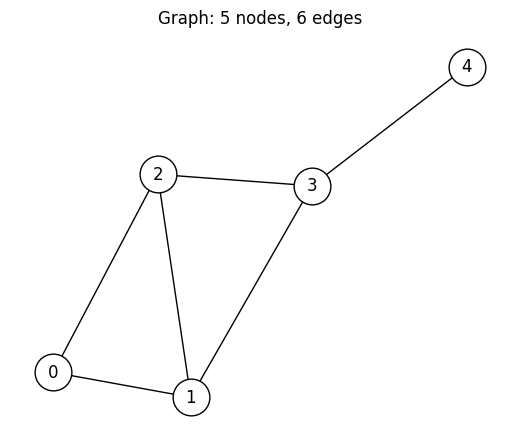

In [3]:
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()
assert num_nodes == 5
assert G.number_of_edges() == 6

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

### Ising Formulation

Maximizing $\sum_{(i,j) \in E} (1 - s_i s_j) / 2$ is equivalent (up to a
constant) to *minimizing* the antiferromagnetic Ising Hamiltonian

$$
H_C(\boldsymbol{s}) = \sum_{(i,j) \in E} s_i s_j.
$$

Compared to the general Ising form
$H = \sum_i h_i s_i + \sum_{i < j} J_{ij} s_i s_j$, unweighted MaxCut has:

- **no linear terms**: $h_i = 0$ for every vertex, and
- **uniform couplings**: $J_{ij} = 1$ for every edge $(i, j) \in E$.

`BinaryModel.from_ising` takes the Ising coefficients directly — there is
no need to go through a QUBO and convert variable types.

In [4]:
ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}

# For weighted MaxCut or spin-glass instances where the J_{ij} are not all
# of the same magnitude, append `.normalize_by_abs_max()` here to stabilize
# convergence with gradient-free optimizers such as COBYLA.
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)

print(f"Variable type:          {spin_model.vartype}")
print(f"Linear terms (h_i):     {spin_model.linear}")
print(f"Quadratic terms (J_ij): {spin_model.quad}")
print(f"Constant:               {spin_model.constant}")
# Spin-domain model with no linear field, one J_ij per graph edge, no offset.
assert spin_model.vartype.name == "SPIN"
assert spin_model.linear == {}
assert len(spin_model.quad) == G.number_of_edges()
assert spin_model.constant == 0.0

Variable type:          SPIN
Linear terms (h_i):     {}
Quadratic terms (J_ij): {(0, 1): 1.0, (0, 2): 1.0, (1, 2): 1.0, (1, 3): 1.0, (2, 3): 1.0, (3, 4): 1.0}
Constant:               0.0


:::{note}
`BinaryModel` also provides `from_qubo()` and `from_hubo()` for problems that
are naturally expressed in the binary domain (e.g., assignment problems,
constrained problems with penalty terms). See
[QAOA for Graph Partitioning](qaoa_graph_partition) for a QUBO /
JijModeling-based workflow.
:::

### Exact Solution (Brute Force)

Before running QAOA, let's find the optimal partition by trying all
$2^n = 32$ spin configurations. This gives us a ground truth to compare
against.

In [5]:
best_cut = 0
optimal_partitions: list[tuple[int, ...]] = []

for spins in itertools.product([+1, -1], repeat=num_nodes):
    cut = sum(1 for i, j in G.edges() if spins[i] != spins[j])
    if cut > best_cut:
        best_cut = cut
        optimal_partitions = [spins]
    elif cut == best_cut:
        optimal_partitions.append(spins)

print(f"Optimal MaxCut value: {best_cut}")
print(f"Number of optimal partitions: {len(optimal_partitions)}")
for part in optimal_partitions:
    print(f"  {part}")
# The MaxCut of this fixed 5-node, 6-edge graph is 5; it is achieved by
# exactly two spin configurations related by the global flip s -> -s.
assert best_cut == 5
assert len(optimal_partitions) == 2
for part in optimal_partitions:
    assert tuple(-s for s in part) in optimal_partitions

Optimal MaxCut value: 5
Number of optimal partitions: 2
  (1, -1, -1, 1, -1)
  (-1, 1, 1, -1, 1)


## Algorithm

QAOA, introduced by Farhi, Goldstone, and Gutmann
{cite:p}`10.48550/arXiv.1411.4028`, is a hybrid quantum-classical variational
algorithm for combinatorial optimization. It encodes the objective function
in a cost Hamiltonian $H_C$ and uses a mixer Hamiltonian $H_M$ to explore
different candidate solutions. A parameterized quantum circuit, called an
ansatz, prepares a parameterized state, and a classical optimizer updates
the parameters to minimize the expected cost $\langle H_C \rangle$.

At depth $p$, QAOA alternates $p$ time-evolution operators generated by the
cost and mixer Hamiltonians. The cost-Hamiltonian evolution assigns phases
according to the objective value. The mixer-Hamiltonian evolution mixes
amplitudes between computational-basis states and promotes transitions through
the search space. After optimization, measurement is more likely to return
low-energy states of the cost Hamiltonian. For MaxCut, these states correspond
to larger cuts.

The QAOA ansatz prepares a parameterized quantum state:

$$
|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle
= \prod_{l=1}^{p}
  e^{-i \beta_l H_M} \, e^{-i \gamma_l H_C}
  \; |{+}\rangle^{\otimes n}
$$

where:
- $|{+}\rangle^{\otimes n}$: uniform superposition state (Hadamard on every qubit)
- $e^{-i \gamma H_C}$: **cost unitary** — for the Ising cost $H_C$, this
  decomposes into $\text{RZZ}$ gates for quadratic terms and $\text{RZ}$
  gates for linear terms.
- $e^{-i \beta H_M}$: **mixer unitary** — with $H_M = \sum_i X_i$, this
  becomes $\text{RX}(2\beta)$ on every qubit.
- $p$: number of layers (depth of the ansatz)

The spin $\leftrightarrow$ computational-basis correspondence is the
standard quantum convention $Z|0\rangle = |0\rangle$,
$Z|1\rangle = -|1\rangle$, so measurement outcome $0$ maps to spin $+1$
and outcome $1$ maps to spin $-1$.

## Implementation with Qamomile

Now let's implement each component as a `@qkernel`.

### From-Scratch Implementation

We first build each part of the QAOA circuit ourselves with Qamomile's
low-level circuit primitives and transpile the complete ansatz for
optimization.

#### Step 1: Prepare the Uniform Superposition State

Apply a Hadamard gate to every qubit to start from the uniform
superposition state $|{+}\rangle^{\otimes n}$.

In [6]:
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q

#### Step 2: Cost Layer

Apply the cost unitary $e^{-i \gamma H_C}$.

:::{note}
Qamomile's rotation gates include a $1/2$ factor:
$\text{RZ}(\theta) = e^{-i \theta Z / 2}$ and
$\text{RZZ}(\theta) = e^{-i \theta Z \otimes Z / 2}$.
To match $e^{-i \gamma H_C}$ exactly, we therefore pass
$2 J_{ij} \gamma$ to `rzz` and $2 h_i \gamma$ to `rz`.
:::

We keep the `linear` argument even though it is empty for unweighted
MaxCut — this makes the kernel immediately reusable for weighted MaxCut
and generic spin-glass Hamiltonians, which do include linear $h_i$ terms.

In [7]:
@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=2.0 * Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=2.0 * hi * gamma)
    return q

#### Step 3: Mixer Layer

Apply the mixer unitary $e^{-i \beta H_M}$ where $H_M = \sum_i X_i$.
Since $\text{RX}(\theta) = e^{-i \theta X / 2}$, we need $\theta = 2\beta$
to implement $e^{-i \beta X_i}$ on each qubit.

In [8]:
@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q

#### Step 4: Build the QAOA Ansatz

The `qaoa_ansatz` qkernel combines the circuit components defined above.
It first prepares all $n$ qubits in a uniform superposition. It then applies
$p$ layers in sequence; layer $l$ uses $\gamma_l$ for the cost layer and
$\beta_l$ for the mixer layer. Finally, it measures every qubit and returns
the bit string used to evaluate a candidate cut.

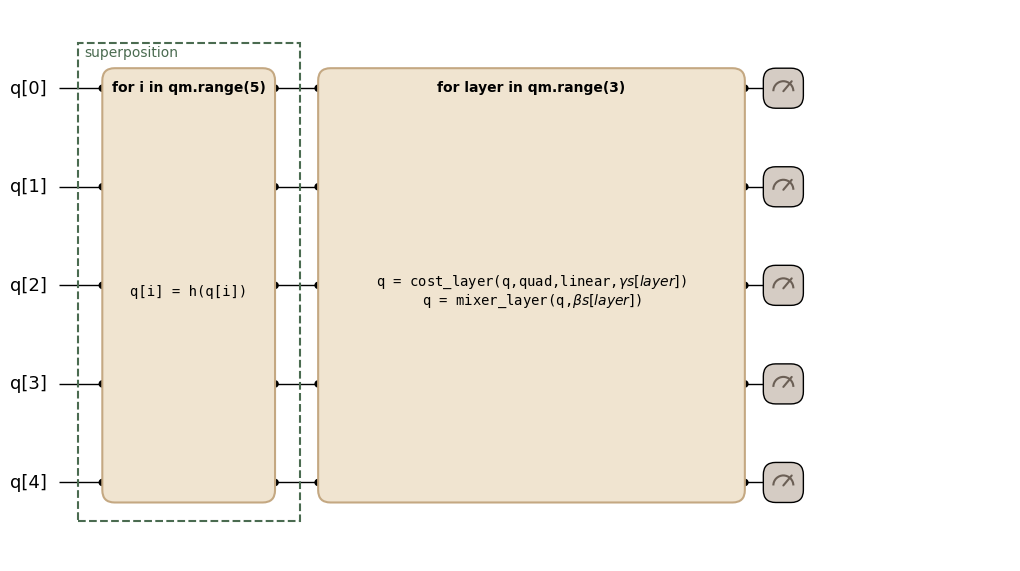

In [9]:
@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)


qaoa_ansatz.draw(
    p=3,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
    inline=True,
    fold_loops=True,
)

#### Transpile the Circuit

We transpile the Qamomile qkernel so that it can run on a simulator. We bind
the problem structure (Ising coefficients, number of qubits, number of
layers) while keeping `gammas` and `betas` as runtime parameters that the
optimizer will tune.
`QiskitTranspiler` converts the Qamomile qkernel into a Qiskit circuit that
can be executed with Qiskit's `AerSimulator`.

In [10]:
transpiler = QiskitTranspiler()
p = 3  # number of QAOA layers

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

### Using `qaoa_state`

`qamomile.circuit.algorithm.qaoa_state` already combines the superposition,
cost layer, mixer layer, and repeated layer structure implemented above. It
accepts the same Ising coefficients (`quad`, `linear`) and variational
parameters (`gammas`, `betas`). This lets us construct the QAOA state without
defining each component separately.

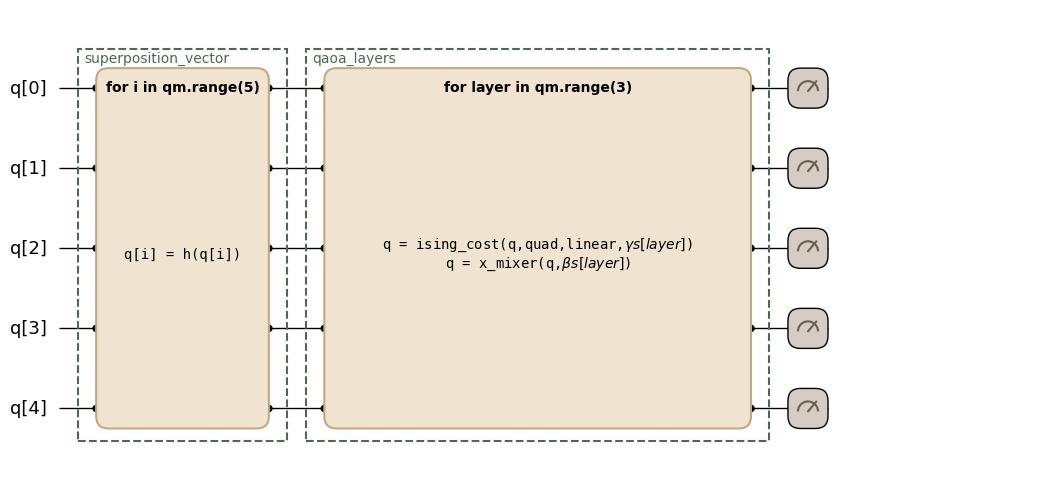

In [11]:
@qmc.qkernel
def qaoa_builtin(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p=p, quad=quad, linear=linear, n=n, gammas=gammas, betas=betas)
    return qmc.measure(q)


qaoa_builtin.draw(
    p=3,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
    inline=True,
    fold_loops=True,
)

## Result

Now let's use the QAOA circuit we implemented to solve the MaxCut problem.

### Optimize the Parameters

QAOA updates its parameters to minimize the objective function. In this
example, we use COBYLA, which does not require gradient calculations.
`scipy.optimize.minimize` optimizes parameters from an objective function.
For each parameter set, `cost_fn` samples the circuit and evaluates the mean
energy from those samples. Passing `cost_fn` to `scipy.optimize.minimize`
performs the parameter optimization. We also record the mean energy for each
parameter set in `cost_history` so that we can inspect the optimization
process later.

To make the tutorial reproducible, we pass `seed_simulator=SEED` to
`AerSimulator` so the per-shot pseudo-random sampling is deterministic, seed
the NumPy generator with the same value so the initial variational parameters
are stable, and set `max_parallel_threads=1` so the simulator does not
interleave random draws across threads. The single-thread setting trades a
little performance for fully reproducible runs; in production code you can
drop it or enable it only in tests and documentation builds.

In [12]:
SEED = 42


def make_seeded_backend() -> AerSimulator:
    """Fresh AerSimulator with deterministic sampling for this tutorial."""
    return AerSimulator(seed_simulator=SEED, max_parallel_threads=1)


executor = transpiler.executor(backend=make_seeded_backend())
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2048
maxiter = 20 if docs_test_mode else 500
cost_history: list[float] = []


def cost_fn(params):
    gammas = list(params[:p])
    betas = list(params[p:])
    result = executable.sample(
        executor,
        shots=sample_shots,
        bindings={"gammas": gammas, "betas": betas},
    ).result()
    decoded = spin_model.decode_from_sampleresult(result)
    energy = decoded.energy_mean()
    cost_history.append(energy)
    return energy


rng = np.random.default_rng(SEED)
initial_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
assert initial_params.shape == (2 * p,)

res = minimize(cost_fn, initial_params, method="COBYLA", options={"maxiter": maxiter})

print(f"Optimized cost: {res.fun:.4f}")
print(f"Optimal params: {[round(v, 4) for v in res.x]}")
assert len(cost_history) == res.nfev
assert len(res.x) == 2 * p
if docs_test_mode:
    # In docs test mode COBYLA is truncated at the maxiter budget.
    assert res.nfev == maxiter

Optimized cost: -0.8203
Optimal params: [np.float64(0.8871), np.float64(-0.1645), np.float64(2.0864), np.float64(0.7465), np.float64(-1.292), np.float64(1.4783)]


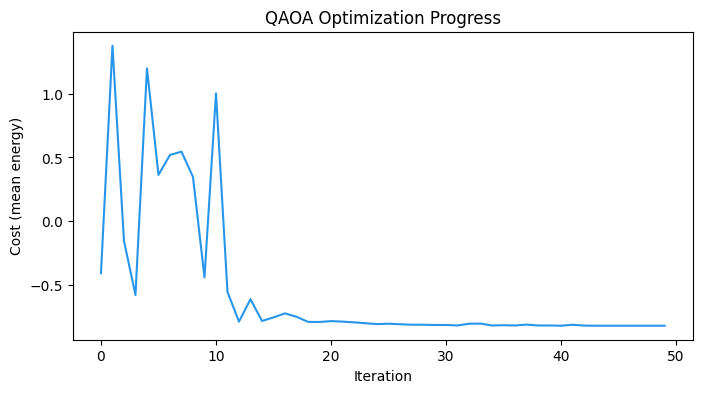

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean energy)")
plt.title("QAOA Optimization Progress")
plt.show()

### Decode and Analyze Results

We sample the circuit with the optimized parameters to obtain the result.
Quantum-circuit measurement outcomes are decoded according to the
corresponding classical variable type, either binary or spin.
`decode_from_sampleresult` returns spin-variable samples (+1 / -1), so we can
count cut edges directly.

In [14]:
gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])

final_result = executable.sample(
    executor,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

decoded = spin_model.decode_from_sampleresult(final_result)

In [15]:
cut_distribution: Counter[int] = Counter()
best_qaoa_cut = 0
best_qaoa_sample = None

for sample, _energy, occ in zip(
    decoded.samples, decoded.energy, decoded.num_occurrences
):
    # sample is a dict {vertex_index: spin_value (+1 or -1)}
    spins = [sample[i] for i in range(num_nodes)]
    cut = sum(1 for i, j in G.edges() if spins[i] != spins[j])
    cut_distribution[cut] += occ
    if cut > best_qaoa_cut:
        best_qaoa_cut = cut
        best_qaoa_sample = spins

print(f"Best QAOA cut: {best_qaoa_cut}  (optimal: {best_cut})")
print(f"Best partition (spins): {best_qaoa_sample}")
# QAOA cannot exceed the brute-force optimum, and the distribution must
# account for every shot of the final sample.
assert best_qaoa_cut <= best_cut
assert sum(cut_distribution.values()) == sample_shots

Best QAOA cut: 5  (optimal: 5)
Best partition (spins): [1, -1, -1, 1, -1]


The workflow above can also be run in the same way with the built-in
`qaoa_state`.

Let's build the same circuit using the built-in function to confirm that it
implements the same structure. Each executor below is instantiated with the
same `seed_simulator=SEED`. Under a fixed seed, identical circuits yield
identical sample sequences and therefore identical mean energies. A
finite-shot estimate still contains shot noise even when the seed is fixed.
Therefore, if the two printed mean energies differ, the manual and built-in
routes did not emit bit-identical circuits, for example because of a gate
ordering or compilation difference; shot noise is not the cause.

In [16]:
exe_builtin = transpiler.transpile(
    qaoa_builtin,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

executor_manual = transpiler.executor(backend=make_seeded_backend())
executor_builtin = transpiler.executor(backend=make_seeded_backend())

result_manual = executable.sample(
    executor_manual,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

result_builtin = exe_builtin.sample(
    executor_builtin,
    shots=sample_shots,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

decoded_manual = spin_model.decode_from_sampleresult(result_manual)
decoded_builtin = spin_model.decode_from_sampleresult(result_builtin)
print(f"Manual   mean energy: {decoded_manual.energy_mean():.4f}")
print(f"Built-in mean energy: {decoded_builtin.energy_mean():.4f}")
# Same seed + bit-identical circuit ⇒ identical samples ⇒ identical mean.
# Any divergence here means the manual and built-in paths emitted different
# circuits (gate ordering, compilation difference) — not shot noise.
assert decoded_manual.energy_mean() == decoded_builtin.energy_mean()

Manual   mean energy: -0.8203
Built-in mean energy: -0.8203


We first aggregate the final samples by cut size. The bar height shows how
often QAOA produced each cut value, making it easy to see whether the sampled
distribution is concentrated near the optimum.

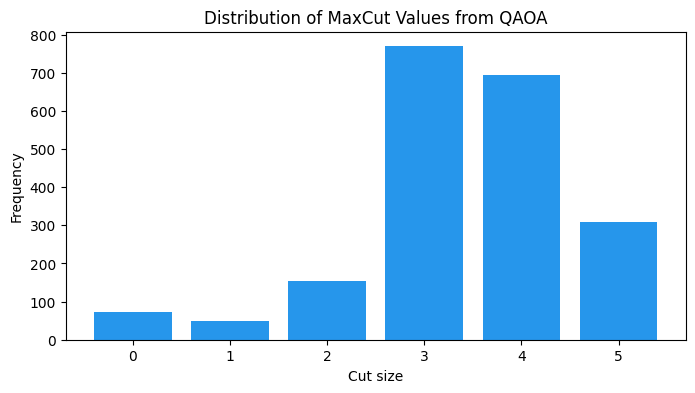

In [17]:
cuts = sorted(cut_distribution.keys())
counts = [cut_distribution[c] for c in cuts]
near_optimal_shots = sum(
    count for cut, count in cut_distribution.items() if cut >= best_cut - 2
)
# Here, "near" means within two cut edges of the known optimum.
assert near_optimal_shots / sample_shots > 0.8

plt.figure(figsize=(8, 4))
plt.bar([str(c) for c in cuts], counts, color="#2696EB")
plt.xlabel("Cut size")
plt.ylabel("Frequency")
plt.title("Distribution of MaxCut Values from QAOA")
plt.show()

The final-sample distribution is concentrated near the previously computed
optimum of 5.

We then visualize the best partition observed in the final samples. Node
colors indicate the two spin groups, so edges connecting different colors
are cut edges; the title reports the resulting cut size.

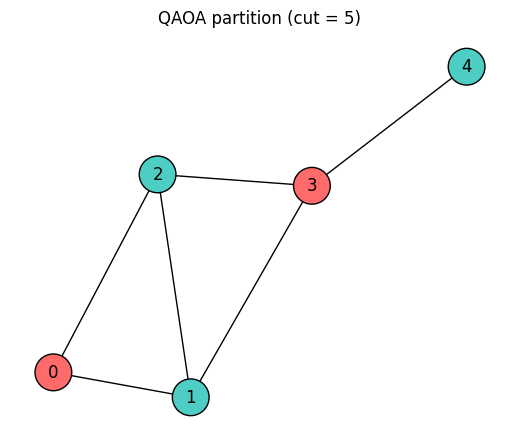

In [18]:
if best_qaoa_sample is not None:
    color_map = [
        "#FF6B6B" if best_qaoa_sample[i] == +1 else "#4ECDC4" for i in range(num_nodes)
    ]
    plt.figure(figsize=(5, 4))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=color_map,
        node_size=700,
        edgecolors="black",
    )
    plt.title(f"QAOA partition (cut = {best_qaoa_cut})")
    plt.show()

## Summary

In this tutorial we:

1. Defined a MaxCut problem and wrote it *directly* as an Ising
   Hamiltonian on spin variables — no QUBO / binary-variable detour.
2. Built the spin-domain `BinaryModel` with `BinaryModel.from_ising`.
3. Built every component of the QAOA circuit as a `@qkernel` —
   superposition, cost layer, mixer layer, and the full ansatz.
4. Ran a classical optimization loop and decoded the spin-domain
   results.
5. Verified that `qamomile.circuit.algorithm.qaoa_state` provides the same
   circuit with a single function call.

The same spin-first recipe applies to any Ising-like problem —
spin-glass ground-state search, weighted MaxCut, Sherrington–Kirkpatrick
model, and so on: plug the $h_i$ and $J_{ij}$ coefficients into
`BinaryModel.from_ising` and reuse the circuit components above. For problems
that are naturally expressed with binary variables or require constraints
(penalty terms), see [QAOA for Graph Partitioning](qaoa_graph_partition),
which uses the higher-level `QAOAConverter` together with JijModeling.